# PT-Mark on Google Colab

Run this notebook after placing your `pt-mark` project folder in Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [19]:

%cd /content
!git clone https://github.com/ademladhari/pt-markown
!dir
%cd pt-markown

/content
Cloning into 'pt-markown'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 131 (delta 61), reused 105 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 1.40 MiB | 1.39 MiB/s, done.
Resolving deltas: 100% (61/61), done.
pt-markown  rere  sample_data
/content/pt-markown


In [2]:
# Edit this path if your folder location differs
PROJECT_DIR = '/content/drive/MyDrive/pt-mark'

import os
assert os.path.exists(PROJECT_DIR), f'Project folder not found: {PROJECT_DIR}'
os.chdir(PROJECT_DIR)
print('Working dir:', os.getcwd())

AssertionError: Project folder not found: /content/drive/MyDrive/pt-mark

In [ ]:
!nvidia-smi

In [16]:
# Optional: create and use venv inside Colab runtime
# Uncomment if you explicitly want venv behavior in Colab.
# !python -m venv .venv
# !. .venv/bin/activate && python -V

# Install requirements in the Colab runtime environment
!python -m pip install --upgrade pip
!pip install --no-cache-dir -r requirements.txt

In [3]:
import torch
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [21]:
# Change prompt/seed as needed
PROMPT = "A fantasy innkeeper portrait"
SEED = 42
OUTDIR = "runs/single_colab"

# Paper defaults from PT-Mark: 50 diffusion steps and 10 null-text optimization steps.
!python scripts/run_single_ptmark.py --prompt "$PROMPT" --seed $SEED --outdir "$OUTDIR" --num-inference-steps 50 --null-opt-steps 10

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline components...:   0% 0/6 [00:00<?, ?it/s]
Loading weights:   0% 0/372 [00:00<?, ?it/s]
Loading weights:   0% 1/372 [00:00<00:00, 8756.38it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   0% 1/372 [00:00<00:00, 3833.92it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   1% 2/372 [00:00<00:00, 2431.48it/s, Materializing param=text_model.embeddings.token_embedding.weight]   
Loading weights:   1% 2/372 [00:00<00:00, 2059.56it/s, Materializing param=text_model.embeddings.token_embedding.weight]
Loading weights:   1% 3/372 [00:01<02:04,  2.95it/s, Materializing param=text_model.embeddings.token_embed

In [22]:
!python scripts/verify_single.py --prompt "$PROMPT" --image "$OUTDIR/pt_mark.png"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading pipeline components...:  33% 2/6 [00:12<00:21,  5.44s/it]
Loading weights:   0% 0/372 [00:00<?, ?it/s]
Loading weights:   0% 1/372 [00:00<00:00, 6543.38it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   0% 1/372 [00:00<00:00, 3675.99it/s, Materializing param=text_model.embeddings.position_embedding.weight]
Loading weights:   1% 2/372 [00:00<00:00, 4000.29it/s, Materializing param=text_model.embeddings.token_embedding.weight]   
Loading weights:   1% 2/372 [00:00<00:00, 3517.24it/s, Materializing param=text_model.embeddings.token_embedding.weight]
Loading weights:   1% 3/372 [00:01<02:58,  2.06it/s, Materializing param=text_model.embeddings.tok

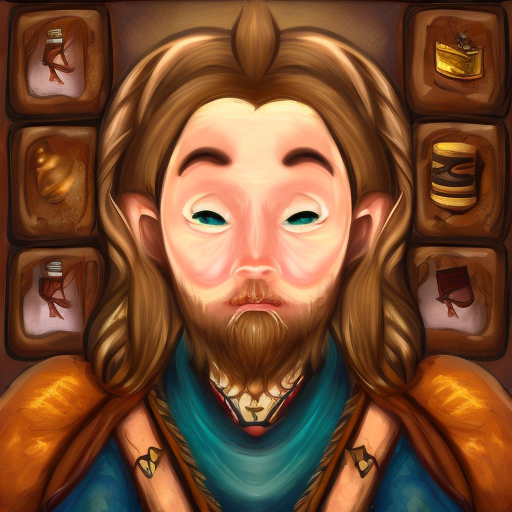

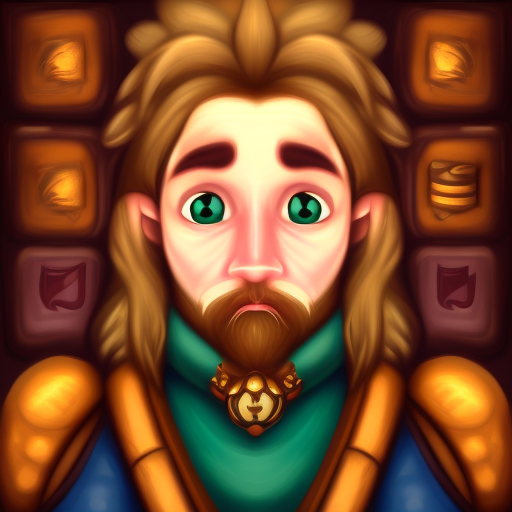

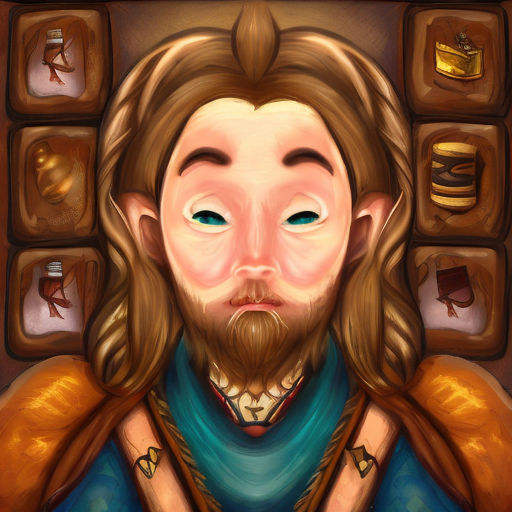

In [23]:
from IPython.display import Image, display

display(Image(filename=f"{OUTDIR}/clean.png"))
display(Image(filename=f"{OUTDIR}/tree_ring_baseline.png"))
display(Image(filename=f"{OUTDIR}/pt_mark.png"))

In [24]:
from PIL import Image
from torchvision.transforms import ToTensor

from src.evaluation.metrics import basic_image_metrics
from src.inversion.ddim import DDIMInverter
from src.pipelines.base_diffusion import DiffusionCore
from src.verification.detector import WatermarkDetector
from src.watermark.tree_ring import TreeRingWatermark
from src.config import ModelConfig, WatermarkConfig

# Evaluation command for the notebook: compute PSNR/SSIM and watermark scores.
core = DiffusionCore(ModelConfig())
inverter = DDIMInverter(core)
watermark = TreeRingWatermark(WatermarkConfig())
detector = WatermarkDetector(watermark)

clean = ToTensor()(Image.open(f"{OUTDIR}/clean.png").convert('RGB')).unsqueeze(0).to(core.cfg.device)
pt_mark = ToTensor()(Image.open(f"{OUTDIR}/pt_mark.png").convert('RGB')).unsqueeze(0).to(core.cfg.device)
baseline = ToTensor()(Image.open(f"{OUTDIR}/tree_ring_baseline.png").convert('RGB')).unsqueeze(0).to(core.cfg.device)

print('PSNR/SSIM (clean vs pt_mark):', basic_image_metrics(clean, pt_mark))
print('PSNR/SSIM (clean vs tree_ring_baseline):', basic_image_metrics(clean, baseline))

for name, path in [('clean', f"{OUTDIR}/clean.png"), ('tree_ring_baseline', f"{OUTDIR}/tree_ring_baseline.png"), ('pt_mark', f"{OUTDIR}/pt_mark.png")]:
    image = ToTensor()(Image.open(path).convert('RGB')).unsqueeze(0).to(core.cfg.device, dtype=core.pipe.unet.dtype)
    z_star = inverter.invert(PROMPT, image)
    payload = watermark.build_payload(z_star[0])
    score = detector.score(z_star[0], payload).mean().item()
    print(f'{name} watermark score: {score:.6f}')

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-1-base/snapshots/4e63672c03103b6c636b8fb4119ba982469b2955/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PSNR/SSIM (clean vs pt_mark): {'psnr': 33.84159832466527, 'ssim': 0.9497696757316589, 'lpips': 0.01582854799926281}
PSNR/SSIM (clean vs tree_ring_baseline): {'psnr': 17.796895846097158, 'ssim': 0.6026320457458496, 'lpips': 0.3520676791667938}
clean watermark score: 61.852917
tree_ring_baseline watermark score: 34.783676
pt_mark watermark score: 44.244942
